In [65]:
import cv2
from utils import generate_2d_points, extract_and_match_SIFT
from plots import draw_homography,draw_matches
from homography import *
import time
import numpy as np
import scipy 
import matplotlib.pyplot as plt

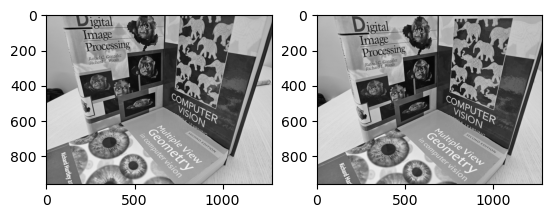

In [ ]:
img1 = cv2.imread('../Lab3/images/books1.jpg', flags=0)
img2 = cv2.imread('../Lab3/images/books2.jpg', flags=0)

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')

In [47]:
pts1, pts2 = extract_and_match_SIFT(img1, img2, num=100)    # top 100 matches

print(pts1.shape)    # array containing the keypoints from img1.
print(pts2.shape)    # array containing the keypoints from img2.

(2, 100)
(2, 100)


In [49]:
print(img1.shape)
print(img2.shape)

(960, 1280)
(960, 1280)


In [51]:
pts1, pts2 = extract_and_match_SIFT(img1, img2, num=100)    # top 100 matches

# convert to homogenous coordinates
pts1_h = np.vstack([pts1, np.ones(pts1.shape[1])])  # 3 x N
pts2_h = np.vstack([pts2, np.ones(pts2.shape[1])])  # 3 x N

N = pts1.shape[1]     # shape is (2, N)
A = []

for i in range(N):
    x, y = pts1[:, i]
    xb, yb = pts2[:, i]    # x', y' in the other image
    A.append([x, y, 1, 0, 0, 0, -x*xb, -y*xb, -xb])
    A.append([0, 0, 0, x, y, 1, -x*yb, -y*yb, -yb])

A = np.array(A)  # shape: 2N x 9

In [52]:
print(A.shape)

(200, 9)


In [53]:
C = np.transpose(A) @ A
print(C.shape)

(9, 9)


In [54]:
U, S, Vh = np.linalg.svd(C)
v = Vh[8,:]   # the eigenvector corresponding to the eigenvalue of C closest to zero

print(v.shape)

(9,)


In [55]:
H = v.reshape(3, 3)
print(H)

[[ 1.19384963e-02 -8.93426782e-05  7.26581259e-01]
 [-6.00304301e-04  1.22263116e-02  6.86739920e-01]
 [-8.83190763e-07 -5.79041374e-07  1.32505458e-02]]


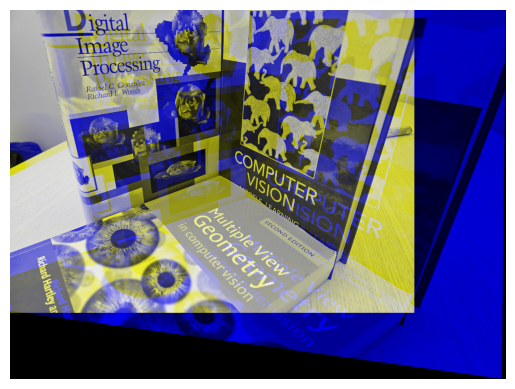

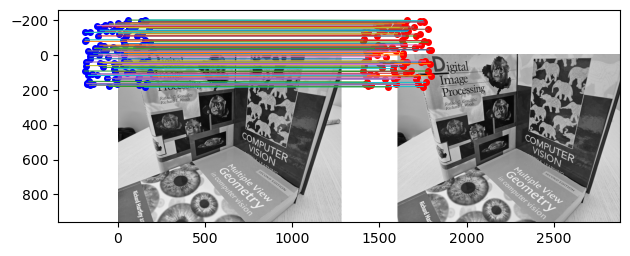

In [ ]:
pts1, pts2, H = generate_2d_points(num=100, noutliers=0, noise = 0.5, vergence = 10.0, focal = 1200)
H = find_homography(pts1, pts2)

# warps image 2 into the coordinate system of image 1 according to the homography H
# blue is image 2 (warped by H) and yellow is image 1
draw_homography(img1, img2, H, save = False) 

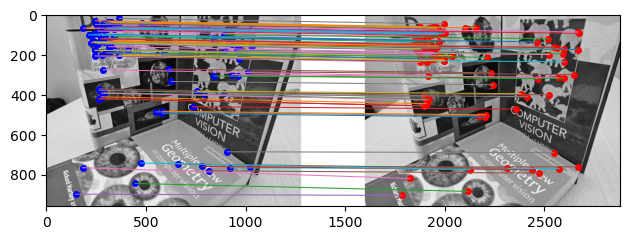

In [46]:
pts1, pts2 = extract_and_match_SIFT(img1, img2, num=100)
draw_matches(pts1, pts2, img1 = img1, img2 = img2)

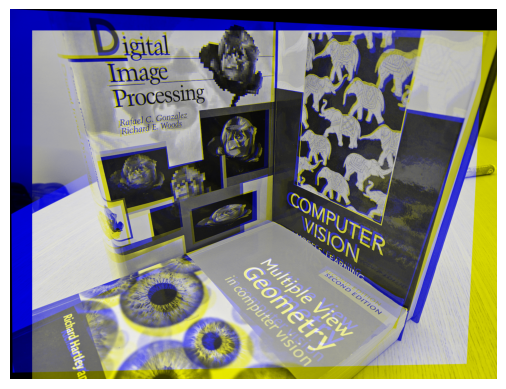

In [60]:
H = find_homography(pts1, pts2)

draw_homography(img1, img2, H, save = False)

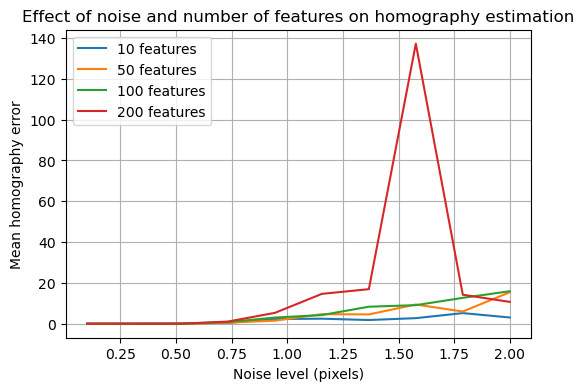

In [ ]:
noise_levels = np.linspace(0.1, 2, 10)
num_features = [10, 50, 100, 200]
repeats = 500
focal=1000

all_errors = {}

for num in num_features:
    mean_errors = []
    for noise in noise_levels:
        errors = []
        for _ in range(repeats):   # to get some average result since it changes every time
            # Generate synthetic points
            pts1, pts2, H_true = generate_2d_points(    # assumes that we have the camera matrix
                num=num,
                noutliers=0,
                noise=noise,
                vergence=10.0,
                focal=focal
            )
            
            # estimated homography
            H_est = find_homography(pts1, pts2)
            err = homography_error(H_est, H_true, focal=focal)
            errors.append(err)
            
        mean_errors.append(np.mean(errors))
    
    all_errors[num] = mean_errors


plt.figure(figsize=(6, 4))
for num, errors in all_errors.items():
    plt.plot(noise_levels, errors, label=f'{num} features')

plt.xlabel("Noise level (pixels)")
plt.ylabel("Mean homography error")
plt.title("Effect of noise and number of features on homography estimation")
plt.grid(True)
plt.legend()
plt.show()

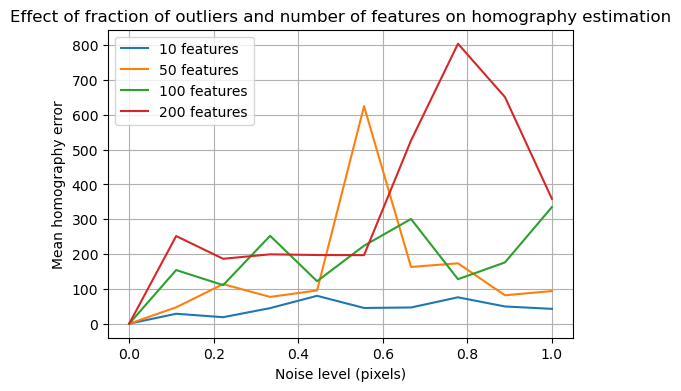

In [ ]:
fraction_outliers_range = np.linspace(0, 1, 10)  # from no outliers to 100% outliers
num_features = [10, 50, 100, 200]
repeats = 500
focal=1000

all_errors = {}

for num in num_features:
    mean_errors = []
    for noutliers_fraction in fraction_outliers_range:
        errors = []
        for _ in range(repeats):   # to get some average result since it changes every time
            # Generate synthetic points
            pts1, pts2, H_true = generate_2d_points(      # assumes that we have the camera matrix
                num=num,
                noutliers= round(num * noutliers_fraction),   # round to nearest integer
                noise=0.5,
                vergence=10.0,
                focal=focal
            )
            
            # estimated homography
            H_est = find_homography(pts1, pts2)
            err = homography_error(H_est, H_true, focal=focal)
            errors.append(err)
            
        mean_errors.append(np.mean(errors))
    
    all_errors[num] = mean_errors


plt.figure(figsize=(6, 4))
for num, errors in all_errors.items():
    plt.plot(fraction_outliers_range, errors, label=f'{num} features')

plt.xlabel("Noise level (pixels)")
plt.ylabel("Mean homography error")
plt.title("Effect of fraction of outliers and number of features on homography estimation")
plt.grid(True)
plt.legend()
plt.show()